In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import linregress

plt.style.use("ggplot")

pd.set_option("display.max_columns", None)

In [5]:
fund_master = pd.read_csv(
    "../data/processed/01_fund_master_clean.csv"
)

nav_history = pd.read_csv(
    "../data/processed/02_nav_history_clean.csv",
    parse_dates=["date"]
)

scheme_performance = pd.read_csv(
    "../data/processed/07_scheme_performance_clean.csv"
)

benchmark_indices = pd.read_csv(
    "../data/processed/10_benchmark_indices_clean.csv",
    parse_dates=["date"]
)

In [6]:
fund_master.head()

,amfi_code,fund_house,scheme_name,category,sub_category,plan,launch_date,benchmark,expense_ratio_pct,exit_load_pct,min_sip_amount,min_lumpsum_amount,fund_manager,risk_category,sebi_category_code
0,119551,SBI Mutual Fund,SBI Bluechip Fund - Regular Plan - Growth,Equity,Large Cap,Regular,2006-02-14,NIFTY 100 TRI,1.54,1.0,500,1000,Sohini Andani,Moderate,EC01
1,119552,SBI Mutual Fund,SBI Bluechip Fund - Direct Plan - Growth,Equity,Large Cap,Direct,2013-01-01,NIFTY 100 TRI,0.66,1.0,500,1000,Sohini Andani,Moderate,EC01
2,119598,SBI Mutual Fund,SBI Small Cap Fund - Regular Plan - Growth,Equity,Small Cap,Regular,2009-09-09,BSE 250 SmallCap TRI,1.43,1.0,500,1000,R. Srinivasan,Very High,EC03
3,119599,SBI Mutual Fund,SBI Small Cap Fund - Direct Plan - Growth,Equity,Small Cap,Direct,2013-01-01,BSE 250 SmallCap TRI,0.72,1.0,500,1000,R. Srinivasan,Very High,EC03
4,119120,SBI Mutual Fund,SBI Magnum Gilt Fund - Regular Plan - Growth,Debt,Gilt,Regular,2000-12-30,CRISIL Dynamic Gilt Index,0.77,0.0,500,1000,Dinesh Ahuja,Low,DC02


In [7]:
nav_history.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [8]:
scheme_performance.head()

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,0.89,0.88,1.29,14.0,-21.70,14288,1.54,4,Moderate
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,0.87,0.81,1.29,14.0,-24.43,1231,0.66,3,Moderate
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,0.89,0.94,1.35,25.0,-13.35,19259,1.43,5,Very High
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,1.04,0.93,1.67,25.0,-24.78,36061,0.72,4,Very High
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,0.22,1.52,2.11,4.0,-2.30,24101,0.77,5,Low


In [9]:
nav_history = nav_history.sort_values(
    ["amfi_code", "date"]
)

nav_history["daily_return"] = (
    nav_history.groupby("amfi_code")["nav"]
    .pct_change()
)

nav_history.head()

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


In [10]:
nav_history["daily_return"].describe()

count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64

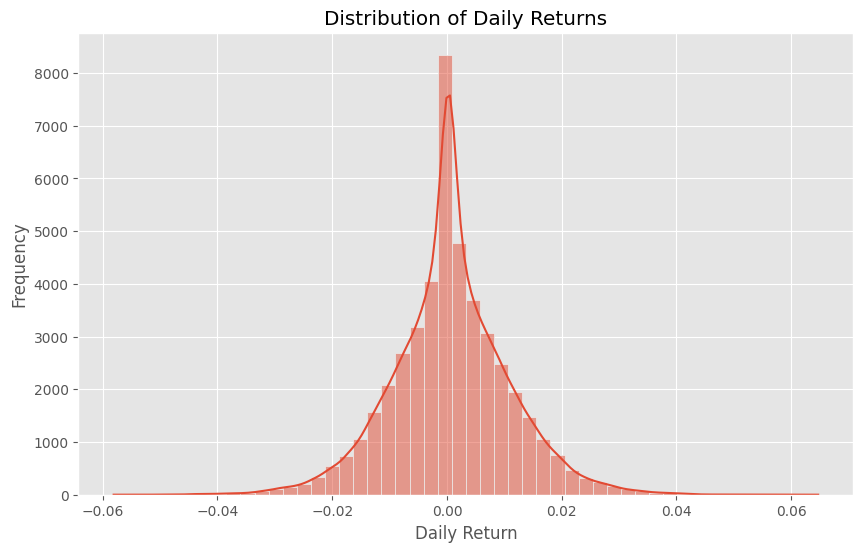

In [11]:
plt.figure(figsize=(10,6))

sns.histplot(
    nav_history["daily_return"].dropna(),
    bins=50,
    kde=True
)

plt.title("Distribution of Daily Returns")

plt.xlabel("Daily Return")

plt.ylabel("Frequency")

plt.show()

In [12]:
def calculate_cagr(group):

    group = group.sort_values("date")

    start_nav = group.iloc[0]["nav"]
    end_nav = group.iloc[-1]["nav"]

    years = (
        group.iloc[-1]["date"]
        - group.iloc[0]["date"]
    ).days / 365.25

    if years <= 0:
        return np.nan

    cagr = (
        (end_nav / start_nav)
        ** (1 / years)
        - 1
    )

    return cagr

In [13]:
cagr = (
    nav_history
    .groupby("amfi_code")
    .apply(calculate_cagr)
    .reset_index(name="cagr")
)

In [14]:
cagr = cagr.merge(
    fund_master[
        [
            "amfi_code",
            "scheme_name",
            "fund_house",
            "category"
        ]
    ],
    on="amfi_code",
    how="left"
)

In [15]:
cagr = cagr.sort_values(
    "cagr",
    ascending=False
)

cagr.head(10)

,amfi_code,cagr,scheme_name,fund_house,category
25,120505,0.328274,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF,Equity
21,119598,0.324235,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Equity
39,149324,0.322874,DSP Small Cap Fund - Regular - Growth,DSP Mutual Fund,Equity
36,148569,0.319495,Mirae Asset Tax Saver Fund - Regular - Growth,Mirae Asset MF,Equity
34,148567,0.309741,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF,Equity
30,120843,0.309075,Kotak Flexicap Fund - Regular - Growth,Kotak Mahindra MF,Equity
2,100033,0.301232,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund,Equity
38,149323,0.295811,DSP Midcap Fund - Regular - Growth,DSP Mutual Fund,Equity
16,119094,0.282144,Axis Midcap Fund - Regular - Growth,Axis Mutual Fund,Equity
19,119551,0.258047,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Equity


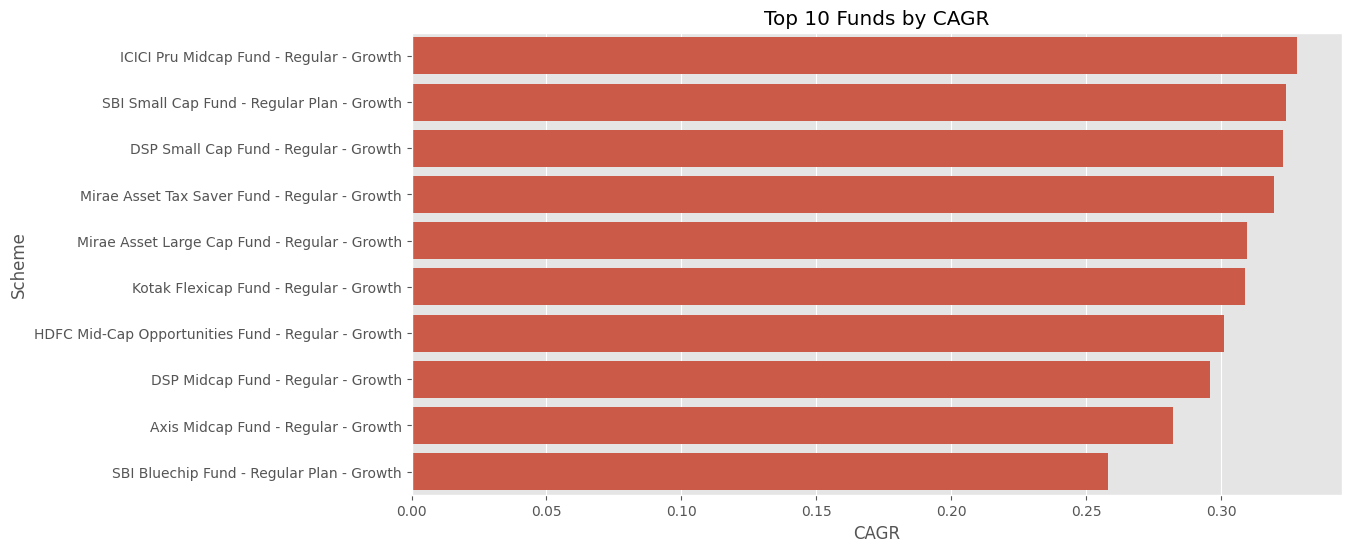

In [16]:
plt.figure(figsize=(12,6))

top10 = cagr.head(10)

sns.barplot(
    data=top10,
    x="cagr",
    y="scheme_name"
)

plt.title("Top 10 Funds by CAGR")

plt.xlabel("CAGR")

plt.ylabel("Scheme")

plt.show()

In [17]:
cagr.describe()

,amfi_code,cagr
count,40.000000,40.000000
mean,120247.000000,0.167357
std,14534.998667,0.103090
min,100016.000000,0.011717
25%,118632.750000,0.068618
50%,119551.500000,0.166073
75%,120842.250000,0.244883
max,149324.000000,0.328274


In [18]:
risk_free_rate = 0.065
trading_days = 252

In [19]:
sharpe_results = []

for amfi_code, group in nav_history.groupby("amfi_code"):

    returns = group["daily_return"].dropna()

    if len(returns) < 30:
        continue

    annual_return = returns.mean() * trading_days
    annual_volatility = returns.std() * np.sqrt(trading_days)

    if annual_volatility == 0:
        continue

    sharpe_ratio = (
        annual_return - risk_free_rate
    ) / annual_volatility

    sharpe_results.append({
        "amfi_code": amfi_code,
        "sharpe_ratio": sharpe_ratio
    })

sharpe_df = pd.DataFrame(sharpe_results)

In [20]:
sharpe_df = sharpe_df.merge(

    fund_master[
        [
            "amfi_code",
            "scheme_name",
            "fund_house",
            "category"
        ]
    ],

    on="amfi_code",
    how="left"

)

In [21]:
sharpe_df = sharpe_df.sort_values(
    "sharpe_ratio",
    ascending=False
)

sharpe_df.head(10)

,amfi_code,sharpe_ratio,scheme_name,fund_house,category
34,148567,1.448291,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF,Equity
30,120843,1.306744,Kotak Flexicap Fund - Regular - Growth,Kotak Mahindra MF,Equity
36,148569,1.234930,Mirae Asset Tax Saver Fund - Regular - Growth,Mirae Asset MF,Equity
19,119551,1.208267,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Equity
25,120505,1.180101,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF,Equity
38,149323,1.132122,DSP Midcap Fund - Regular - Growth,DSP Mutual Fund,Equity
2,100033,1.093699,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund,Equity
9,118632,1.081659,Nippon India Large Cap Fund - Regular - Growth,Nippon India MF,Equity
3,101206,1.027213,ABSL Frontline Equity Fund - Regular - Growth,Aditya Birla Sun Life MF,Equity
24,120504,1.026524,ICICI Pru Bluechip Fund - Direct - Growth,ICICI Prudential MF,Equity


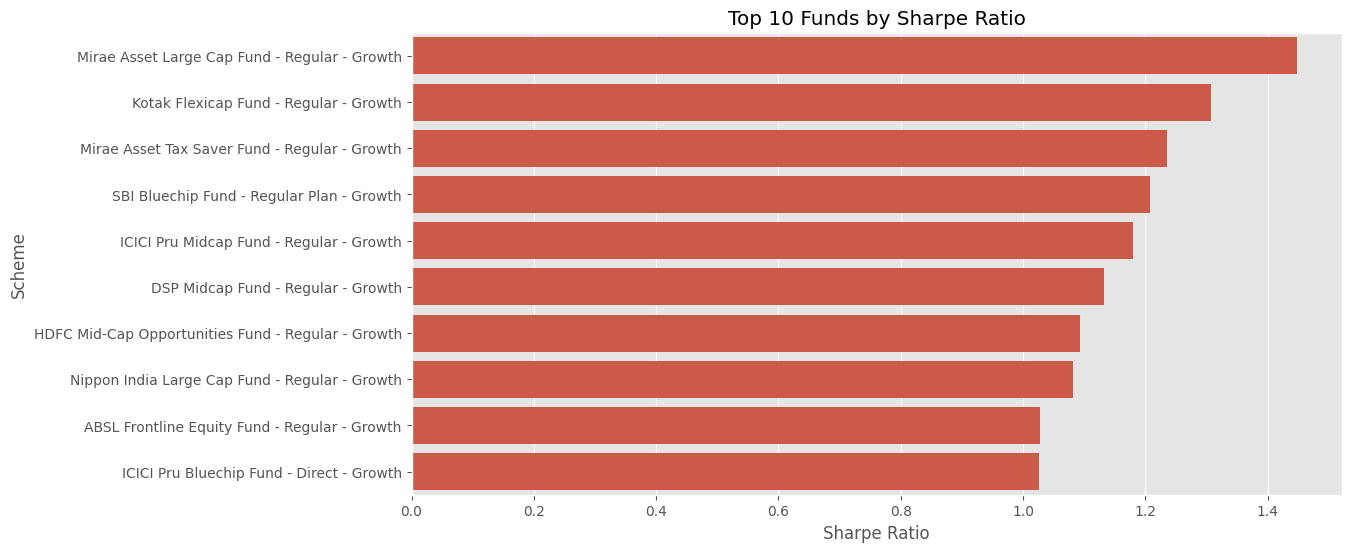

In [22]:
plt.figure(figsize=(12,6))

top10 = sharpe_df.head(10)

sns.barplot(
    data=top10,
    x="sharpe_ratio",
    y="scheme_name"
)

plt.title("Top 10 Funds by Sharpe Ratio")

plt.xlabel("Sharpe Ratio")

plt.ylabel("Scheme")

plt.show()

In [23]:
sharpe_df.describe()

,amfi_code,sharpe_ratio
count,40.000000,40.000000
mean,120247.000000,0.537220
std,14534.998667,0.573689
min,100016.000000,-0.815567
25%,118632.750000,0.064696
50%,119551.500000,0.647043
75%,120842.250000,1.005304
max,149324.000000,1.448291


In [24]:
sharpe_df.to_csv(
    "../reports/sharpe_ratio_report.csv",
    index=False
)

In [25]:
sortino_results = []

In [26]:
for amfi_code, group in nav_history.groupby("amfi_code"):

    returns = group["daily_return"].dropna()

    if len(returns) < 30:
        continue

    downside = returns[returns < 0]

    if len(downside) < 2:
        continue

    annual_return = returns.mean() * trading_days

    downside_deviation = (
        downside.std() * np.sqrt(trading_days)
    )

    if downside_deviation == 0:
        continue

    sortino_ratio = (
        annual_return - risk_free_rate
    ) / downside_deviation

    sortino_results.append({

        "amfi_code": amfi_code,

        "sortino_ratio": sortino_ratio

    })

In [27]:
sortino_df = pd.DataFrame(sortino_results)

In [28]:
sortino_df = sortino_df.merge(

    fund_master[
        [
            "amfi_code",
            "scheme_name",
            "fund_house",
            "category"
        ]
    ],

    on="amfi_code",
    how="left"

)

In [29]:
sortino_df = sortino_df.sort_values(
    "sortino_ratio",
    ascending=False
)

sortino_df.head(10)

,amfi_code,sortino_ratio,scheme_name,fund_house,category
34,148567,2.385644,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF,Equity
30,120843,2.364320,Kotak Flexicap Fund - Regular - Growth,Kotak Mahindra MF,Equity
36,148569,2.146914,Mirae Asset Tax Saver Fund - Regular - Growth,Mirae Asset MF,Equity
19,119551,2.140267,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Equity
25,120505,2.029353,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF,Equity
38,149323,1.875101,DSP Midcap Fund - Regular - Growth,DSP Mutual Fund,Equity
9,118632,1.850133,Nippon India Large Cap Fund - Regular - Growth,Nippon India MF,Equity
2,100033,1.829134,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund,Equity
24,120504,1.805294,ICICI Pru Bluechip Fund - Direct - Growth,ICICI Prudential MF,Equity
3,101206,1.799563,ABSL Frontline Equity Fund - Regular - Growth,Aditya Birla Sun Life MF,Equity


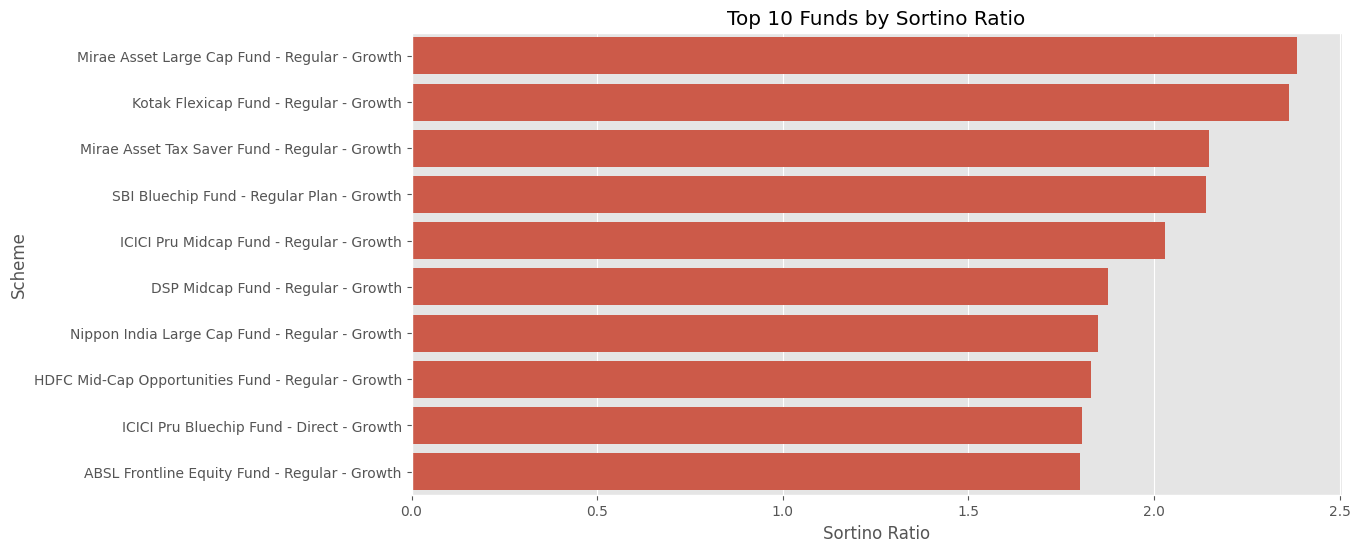

In [30]:
plt.figure(figsize=(12,6))

top10 = sortino_df.head(10)

sns.barplot(

    data=top10,

    x="sortino_ratio",

    y="scheme_name"

)

plt.title("Top 10 Funds by Sortino Ratio")

plt.xlabel("Sortino Ratio")

plt.ylabel("Scheme")

plt.show()

In [31]:
sortino_df.describe()

,amfi_code,sortino_ratio
count,40.000000,40.000000
mean,120247.000000,0.923338
std,14534.998667,1.005410
min,100016.000000,-1.681038
25%,118632.750000,0.106664
50%,119551.500000,1.116936
75%,120842.250000,1.727739
max,149324.000000,2.385644


In [32]:
sortino_df.to_csv(

    "../reports/sortino_ratio_report.csv",

    index=False

)

In [33]:
sharpe_df.columns

Index(['amfi_code', 'sharpe_ratio', 'scheme_name', 'fund_house', 'category'], dtype='str')

In [34]:
benchmark = benchmark_indices[
    benchmark_indices["index_name"]
    .str.upper()
    .str.contains("NIFTY50")
].copy()

benchmark = benchmark.sort_values("date")

benchmark["benchmark_return"] = (
    benchmark["close_value"]
    .pct_change()
)

benchmark.head()

,date,index_name,close_value,benchmark_return
0,2022-01-03,NIFTY50,17492.79,NaN
4600,2022-01-03,NIFTY500,14837.07,-0.151818
4601,2022-01-04,NIFTY500,14743.12,-0.006332
1,2022-01-04,NIFTY50,17689.64,0.199857
2,2022-01-05,NIFTY50,17835.05,0.008220


In [35]:
alpha_beta_results = []

In [36]:
for amfi_code, group in nav_history.groupby("amfi_code"):

    fund = group[["date", "daily_return"]].copy()

    merged = fund.merge(
        benchmark[
            ["date", "benchmark_return"]
        ],
        on="date",
        how="inner"
    )

    merged = merged.dropna()

    if len(merged) < 30:
        continue

    beta, alpha, r_value, p_value, std_err = linregress(

        merged["benchmark_return"],

        merged["daily_return"]

    )

    alpha_beta_results.append({

        "amfi_code": amfi_code,

        "alpha": alpha * 252,

        "beta": beta,

        "r_squared": r_value ** 2

    })

In [37]:
alpha_beta = pd.DataFrame(alpha_beta_results)

alpha_beta.head()

,amfi_code,alpha,beta,r_squared
0,100016,0.037698,-0.000211,0.000043
1,100025,0.043722,-0.000091,0.000111
2,100033,0.264248,0.000822,0.000388
3,101206,0.212058,0.000271,0.000071
4,101207,0.109507,-0.000266,0.000022


In [38]:
alpha_beta = alpha_beta.merge(

    fund_master[
        [
            "amfi_code",
            "scheme_name",
            "fund_house",
            "category"
        ]
    ],

    on="amfi_code",

    how="left"

)

In [39]:
alpha_beta = alpha_beta.sort_values(

    "alpha",

    ascending=False

)

alpha_beta.head(10)

,amfi_code,alpha,beta,r_squared,scheme_name,fund_house,category
39,149324,0.306844,-0.000618,1.273863e-04,DSP Small Cap Fund - Regular - Growth,DSP Mutual Fund,Equity
25,120505,0.300695,-0.000841,3.907709e-04,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF,Equity
21,119598,0.299507,0.000329,3.526715e-05,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Equity
36,148569,0.280350,0.000304,6.103253e-05,Mirae Asset Tax Saver Fund - Regular - Growth,Mirae Asset MF,Equity
30,120843,0.274324,-0.000180,2.641976e-05,Kotak Flexicap Fund - Regular - Growth,Kotak Mahindra MF,Equity
34,148567,0.270833,-0.000028,7.939623e-07,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF,Equity
38,149323,0.266037,-0.000013,1.179748e-07,DSP Midcap Fund - Regular - Growth,DSP Mutual Fund,Equity
16,119094,0.265130,-0.000669,2.447036e-04,Axis Midcap Fund - Regular - Growth,Axis Mutual Fund,Equity
2,100033,0.264248,0.000822,3.875575e-04,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund,Equity
19,119551,0.227247,0.000396,1.706811e-04,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Equity


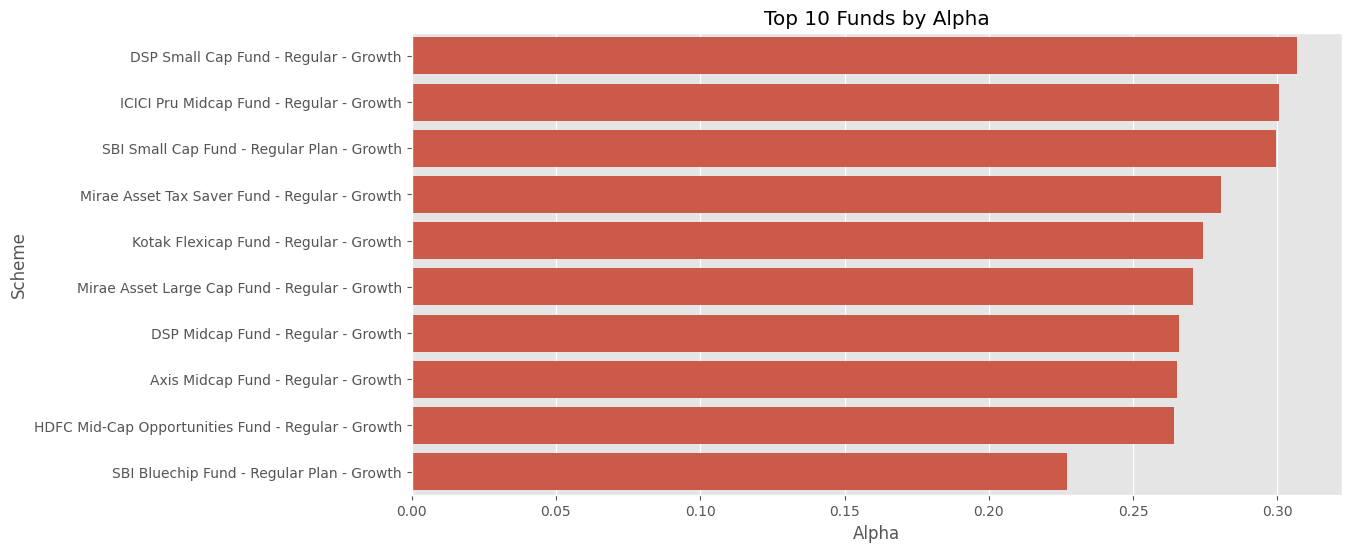

In [40]:
plt.figure(figsize=(12,6))

top10 = alpha_beta.head(10)

sns.barplot(

    data=top10,

    x="alpha",

    y="scheme_name"

)

plt.title("Top 10 Funds by Alpha")

plt.xlabel("Alpha")

plt.ylabel("Scheme")

plt.show()

In [41]:
alpha_beta.to_csv(

    "../reports/alpha_beta.csv",

    index=False

)

In [42]:
drawdown_results = []

In [43]:
for amfi_code, group in nav_history.groupby("amfi_code"):

    temp = group.sort_values("date").copy()

    temp["running_max"] = temp["nav"].cummax()

    temp["drawdown"] = (

        temp["nav"]

        /

        temp["running_max"]

    ) - 1

    max_drawdown = temp["drawdown"].min()

    drawdown_results.append({

        "amfi_code": amfi_code,

        "max_drawdown": max_drawdown

    })

In [44]:
drawdown_df = pd.DataFrame(drawdown_results)

In [45]:
drawdown_df = drawdown_df.merge(

    fund_master[
        [
            "amfi_code",
            "scheme_name",
            "fund_house",
            "category"
        ]
    ],

    on="amfi_code",

    how="left"

)

In [46]:
drawdown_df = drawdown_df.sort_values(

    "max_drawdown"

)

drawdown_df.head(10)

,amfi_code,max_drawdown,scheme_name,fund_house,category
22,119599,-0.525742,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Equity
17,119095,-0.516778,Axis Small Cap Fund - Regular - Growth,Axis Mutual Fund,Equity
4,101207,-0.354469,ABSL Small Cap Fund - Regular - Growth,Aditya Birla Sun Life MF,Equity
39,149324,-0.311719,DSP Small Cap Fund - Regular - Growth,DSP Mutual Fund,Equity
21,119598,-0.287060,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Equity
7,102886,-0.280011,UTI Mid Cap Fund - Regular - Growth,UTI Mutual Fund,Equity
0,100016,-0.247344,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,Equity
29,120842,-0.240035,Kotak Emerging Equity Fund - Regular - Growth,Kotak Mahindra MF,Equity
11,118634,-0.233449,Nippon India Small Cap Fund - Regular - Growth,Nippon India MF,Equity
15,119093,-0.217514,Axis Bluechip Fund - Direct - Growth,Axis Mutual Fund,Equity


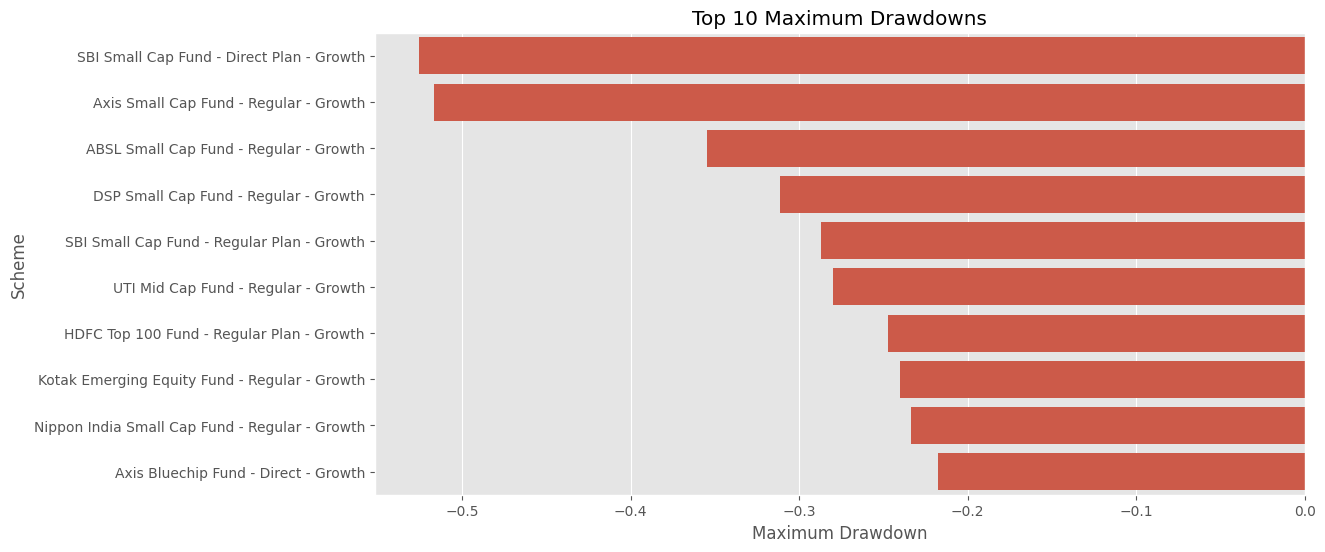

In [47]:
plt.figure(figsize=(12,6))

worst10 = drawdown_df.head(10)

sns.barplot(

    data=worst10,

    x="max_drawdown",

    y="scheme_name"

)

plt.title("Top 10 Maximum Drawdowns")

plt.xlabel("Maximum Drawdown")

plt.ylabel("Scheme")

plt.show()

In [48]:
drawdown_df.to_csv(

    "../reports/drawdown_report.csv",

    index=False

)

In [49]:
alpha_beta.columns

Index(['amfi_code', 'alpha', 'beta', 'r_squared', 'scheme_name', 'fund_house',
       'category'],
      dtype='str')

In [50]:
drawdown_df.columns

Index(['amfi_code', 'max_drawdown', 'scheme_name', 'fund_house', 'category'], dtype='str')

In [51]:
score = (
    scheme_performance[
        [
            "amfi_code",
            "scheme_name",
            "fund_house",
            "category",
            "return_3yr_pct",
            "expense_ratio_pct"
        ]
    ]
    .merge(
        sharpe_df[["amfi_code", "sharpe_ratio"]],
        on="amfi_code",
        how="left"
    )
    .merge(
        alpha_beta[["amfi_code", "alpha"]],
        on="amfi_code",
        how="left"
    )
    .merge(
        drawdown_df[["amfi_code", "max_drawdown"]],
        on="amfi_code",
        how="left"
    )
)

In [52]:
score = score.dropna()

score.head()

,amfi_code,scheme_name,fund_house,category,return_3yr_pct,expense_ratio_pct,sharpe_ratio,alpha,max_drawdown
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,12.36,1.54,1.208267,0.227247,-0.150124
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,11.30,0.66,0.953279,0.203943,-0.118035
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,23.39,1.43,0.945308,0.299507,-0.287060
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,23.14,0.72,-0.057187,0.053354,-0.525742
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,6.07,0.77,-0.226575,0.056997,-0.043287


In [53]:
score["return_score"] = (
    score["return_3yr_pct"].rank(pct=True)
)

score["sharpe_score"] = (
    score["sharpe_ratio"].rank(pct=True)
)

score["alpha_score"] = (
    score["alpha"].rank(pct=True)
)

score["expense_score"] = (
    1 - score["expense_ratio_pct"].rank(pct=True)
)

score["drawdown_score"] = (
    1 - score["max_drawdown"].rank(pct=True)
)

In [54]:
score["fund_score"] = (

      score["return_score"] * 30

    + score["sharpe_score"] * 25

    + score["alpha_score"] * 20

    + score["expense_score"] * 15

    + score["drawdown_score"] * 10

)

In [55]:
score = score.sort_values(
    "fund_score",
    ascending=False
)

score.head(10)

,amfi_code,scheme_name,fund_house,category,return_3yr_pct,expense_ratio_pct,sharpe_ratio,alpha,max_drawdown,return_score,sharpe_score,alpha_score,expense_score,drawdown_score,fund_score
12,120505,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF,Mid Cap,18.08,1.36,1.180101,0.300695,-0.181885,0.825,0.900,0.975,0.6250,0.600,82.1250
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,23.39,1.43,0.945308,0.299507,-0.287060,1.000,0.675,0.950,0.4750,0.875,81.7500
39,149324,DSP Small Cap Fund - Regular - Growth,DSP Mutual Fund,Small Cap,20.08,1.52,0.949796,0.306844,-0.311719,0.875,0.700,1.000,0.3375,0.900,77.8125
22,120843,Kotak Flexicap Fund - Regular - Growth,Kotak Mahindra MF,Flexi Cap,15.65,1.45,1.306744,0.274324,-0.129740,0.750,0.975,0.900,0.4500,0.300,74.6250
7,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund,Mid Cap,16.58,1.38,1.093699,0.264248,-0.162172,0.775,0.850,0.800,0.5750,0.475,73.8750
26,119094,Axis Midcap Fund - Regular - Growth,Axis Mutual Fund,Mid Cap,15.18,1.38,0.998231,0.265130,-0.209609,0.650,0.750,0.825,0.5750,0.675,70.1250
38,149323,DSP Midcap Fund - Regular - Growth,DSP Mutual Fund,Mid Cap,17.16,1.61,1.132122,0.266037,-0.172481,0.800,0.875,0.850,0.0500,0.525,68.8750
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF,Large Cap,14.81,1.46,1.448291,0.270833,-0.112657,0.600,1.000,0.875,0.4250,0.175,68.6250
11,120504,ICICI Pru Bluechip Fund - Direct - Growth,ICICI Prudential MF,Large Cap,14.41,0.80,1.026524,0.215133,-0.125883,0.525,0.775,0.750,0.7000,0.275,63.3750
36,148569,Mirae Asset Tax Saver Fund - Regular - Growth,Mirae Asset MF,ELSS,13.58,1.60,1.234930,0.280350,-0.163967,0.450,0.950,0.925,0.0875,0.500,62.0625


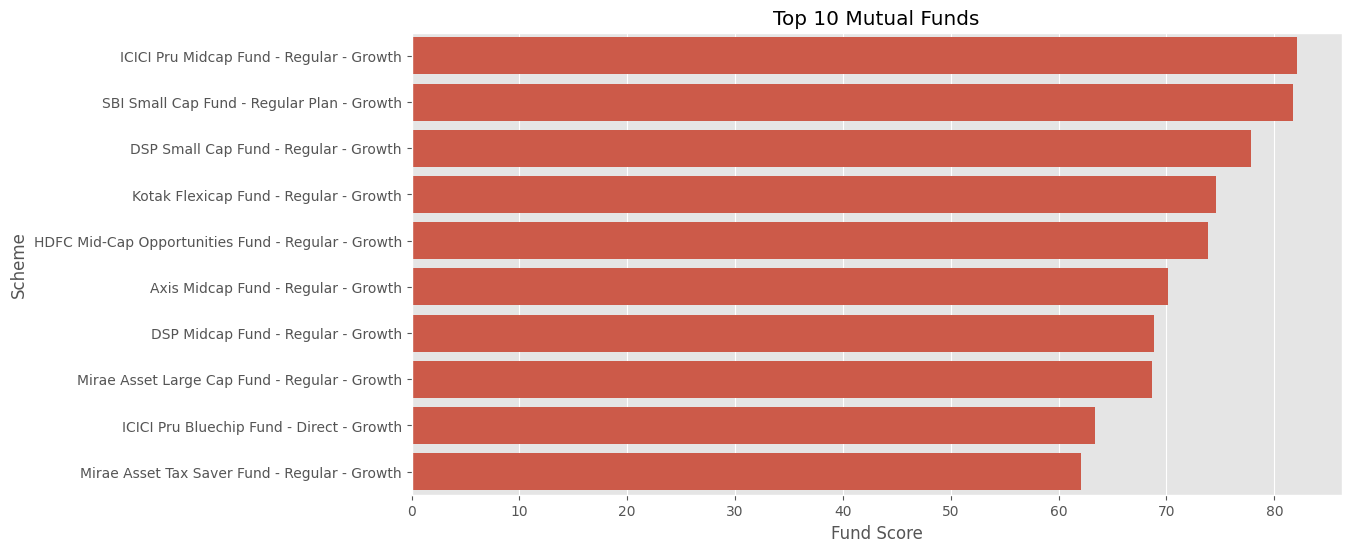

In [56]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=score.head(10),
    x="fund_score",
    y="scheme_name"
)

plt.title("Top 10 Mutual Funds")

plt.xlabel("Fund Score")

plt.ylabel("Scheme")

plt.show()

In [57]:
score.to_csv(
    "../reports/fund_scorecard.csv",
    index=False
)

In [58]:
top5 = score.head(5)["amfi_code"].tolist()

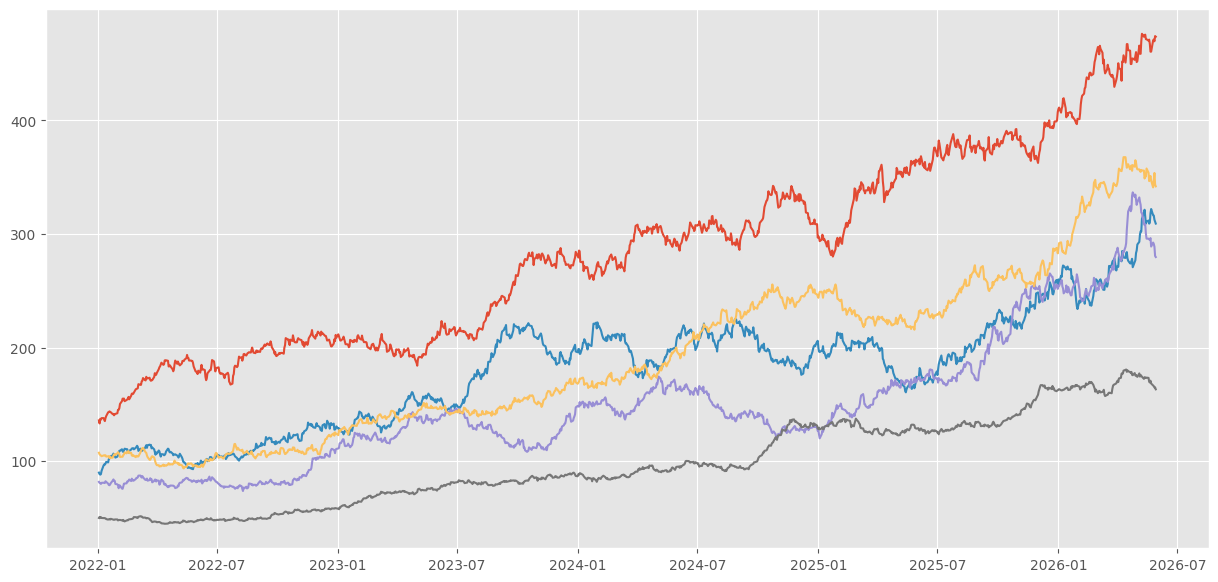

In [59]:
plt.figure(figsize=(15,7))

for code in top5:

    temp = nav_history[
        nav_history["amfi_code"] == code
    ]

    name = score.loc[
        score["amfi_code"] == code,
        "scheme_name"
    ].values[0]

    plt.plot(
        temp["date"],
        temp["nav"],
        label=name
    )

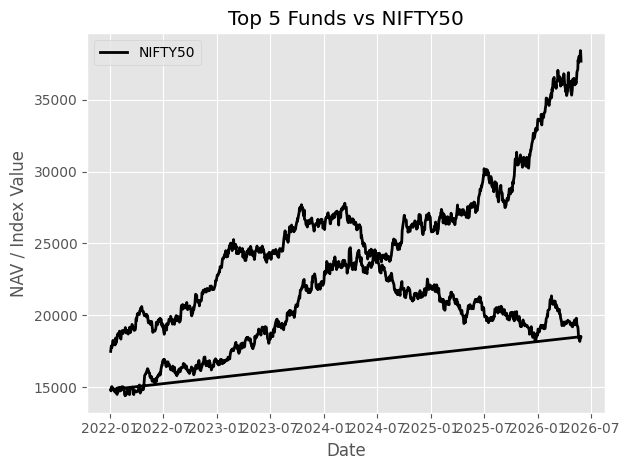

In [60]:
nifty = benchmark_indices[
    benchmark_indices["index_name"]
    .str.upper()
    .str.contains("NIFTY50")
]

plt.plot(
    nifty["date"],
    nifty["close_value"],
    color="black",
    linewidth=2,
    label="NIFTY50"
)

plt.legend()

plt.title("Top 5 Funds vs NIFTY50")

plt.xlabel("Date")

plt.ylabel("NAV / Index Value")

plt.tight_layout()

plt.show()

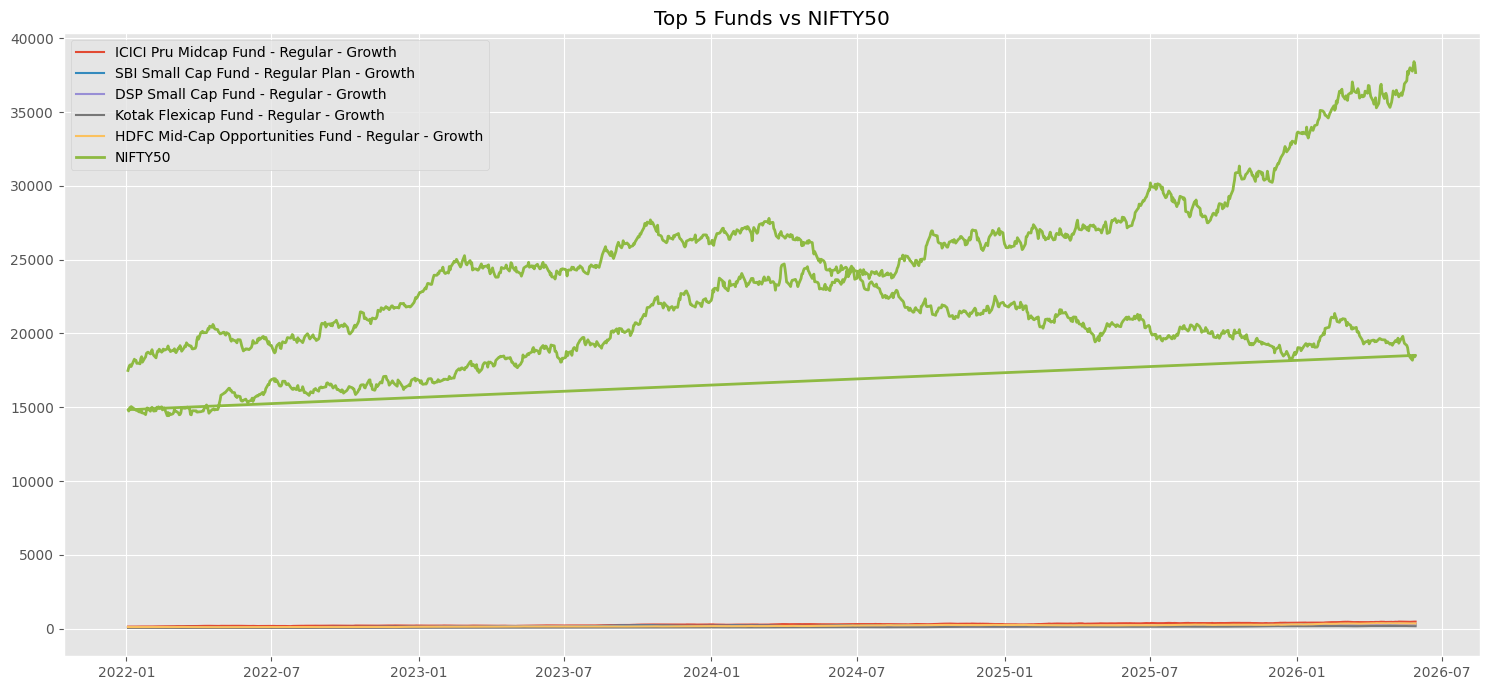

In [61]:
plt.figure(figsize=(15,7))

for code in top5:

    temp = nav_history[
        nav_history["amfi_code"] == code
    ]

    name = score.loc[
        score["amfi_code"] == code,
        "scheme_name"
    ].values[0]

    plt.plot(
        temp["date"],
        temp["nav"],
        label=name
    )

plt.plot(
    nifty["date"],
    nifty["close_value"],
    linewidth=2,
    label="NIFTY50"
)

plt.legend()

plt.title("Top 5 Funds vs NIFTY50")

plt.tight_layout()

plt.savefig(
    "../reports/benchmark_comparison.png",
    dpi=300
)

plt.show()

In [62]:
score.describe()

,amfi_code,return_3yr_pct,expense_ratio_pct,sharpe_ratio,alpha,max_drawdown,return_score,sharpe_score,alpha_score,expense_score,drawdown_score,fund_score
count,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.00000,40.000000,40.000000
mean,120247.000000,14.089000,1.237000,0.537220,0.158891,-0.178729,0.512500,0.512500,0.512500,0.48750,0.487500,50.625000
std,14534.998667,4.617253,0.386584,0.573689,0.087857,0.112686,0.292261,0.292261,0.292261,0.29211,0.292261,17.605309
min,100016.000000,5.140000,0.550000,-0.815567,0.023798,-0.525742,0.025000,0.025000,0.025000,0.01250,0.000000,16.750000
25%,118632.750000,12.035000,0.787500,0.064696,0.069093,-0.215927,0.268750,0.268750,0.268750,0.23750,0.243750,38.046875
50%,119551.500000,14.205000,1.425000,0.647043,0.161896,-0.163070,0.512500,0.512500,0.512500,0.48750,0.487500,52.625000
75%,120842.250000,15.882500,1.540000,1.005304,0.218161,-0.117653,0.756250,0.756250,0.756250,0.73125,0.731250,61.218750
max,149324.000000,23.390000,1.640000,1.448291,0.306844,-0.000977,1.000000,1.000000,1.000000,0.97500,0.975000,82.125000


In [63]:
score.head(20)

,amfi_code,scheme_name,fund_house,category,return_3yr_pct,expense_ratio_pct,sharpe_ratio,alpha,max_drawdown,return_score,sharpe_score,alpha_score,expense_score,drawdown_score,fund_score
12,120505,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF,Mid Cap,18.08,1.36,1.180101,0.300695,-0.181885,0.825,0.900,0.975,0.6250,0.600,82.1250
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,23.39,1.43,0.945308,0.299507,-0.287060,1.000,0.675,0.950,0.4750,0.875,81.7500
39,149324,DSP Small Cap Fund - Regular - Growth,DSP Mutual Fund,Small Cap,20.08,1.52,0.949796,0.306844,-0.311719,0.875,0.700,1.000,0.3375,0.900,77.8125
22,120843,Kotak Flexicap Fund - Regular - Growth,Kotak Mahindra MF,Flexi Cap,15.65,1.45,1.306744,0.274324,-0.129740,0.750,0.975,0.900,0.4500,0.300,74.6250
7,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund,Mid Cap,16.58,1.38,1.093699,0.264248,-0.162172,0.775,0.850,0.800,0.5750,0.475,73.8750
26,119094,Axis Midcap Fund - Regular - Growth,Axis Mutual Fund,Mid Cap,15.18,1.38,0.998231,0.265130,-0.209609,0.650,0.750,0.825,0.5750,0.675,70.1250
38,149323,DSP Midcap Fund - Regular - Growth,DSP Mutual Fund,Mid Cap,17.16,1.61,1.132122,0.266037,-0.172481,0.800,0.875,0.850,0.0500,0.525,68.8750
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF,Large Cap,14.81,1.46,1.448291,0.270833,-0.112657,0.600,1.000,0.875,0.4250,0.175,68.6250
11,120504,ICICI Pru Bluechip Fund - Direct - Growth,ICICI Prudential MF,Large Cap,14.41,0.80,1.026524,0.215133,-0.125883,0.525,0.775,0.750,0.7000,0.275,63.3750
36,148569,Mirae Asset Tax Saver Fund - Regular - Growth,Mirae Asset MF,ELSS,13.58,1.60,1.234930,0.280350,-0.163967,0.450,0.950,0.925,0.0875,0.500,62.0625


In [64]:
print("Performance Analytics Completed Successfully!")
print()

print("Generated Files:")

print("- sharpe_ratio_report.csv")
print("- sortino_ratio_report.csv")
print("- alpha_beta.csv")
print("- drawdown_report.csv")
print("- fund_scorecard.csv")
print("- benchmark_comparison.png")

Performance Analytics Completed Successfully!

Generated Files:
- sharpe_ratio_report.csv
- sortino_ratio_report.csv
- alpha_beta.csv
- drawdown_report.csv
- fund_scorecard.csv
- benchmark_comparison.png
